In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import numpy as np
import SimpleITK as sitk
from scipy import ndimage as ndi
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/xiaoweixumedicalai/imagecas/601-800.change2zip
/kaggle/input/datasets/xiaoweixumedicalai/imagecas/201-400.z02
/kaggle/input/datasets/xiaoweixumedicalai/imagecas/imageCAS_data_split.xlsx
/kaggle/input/datasets/xiaoweixumedicalai/imagecas/401-600.z03
/kaggle/input/datasets/xiaoweixumedicalai/imagecas/801-1000.z04
/kaggle/input/datasets/xiaoweixumedicalai/imagecas/801-1000.z02
/kaggle/input/datasets/xiaoweixumedicalai/imagecas/801-1000.change2zip
/kaggle/input/datasets/xiaoweixumedicalai/imagecas/401-600.z02
/kaggle/input/datasets/xiaoweixumedicalai/imagecas/201-400.z01
/kaggle/input/datasets/xiaoweixumedicalai/imagecas/801-1000.z01
/kaggle/input/datasets/xiaoweixumedicalai/imagecas/1-200.z01
/kaggle/input/datasets/xiaoweixumedicalai/imagecas/601-800.z04
/kaggle/input/datasets/xiaoweixumedicalai/imagecas/601-800.z03
/kaggle/input/datasets/xiaoweixumedicalai/imagecas/601-800.z01
/kaggle/input/datasets/xiaoweixumedicalai/imagecas/201-400.z03
/kaggle/input/datasets/xia

In [2]:
!pip install itk-elastix -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 62.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.9/80.9 MB 21.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 25.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 60.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 28.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 53.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 75.1 MB/s eta 0:00:00:00:0100:01


In [3]:
# Install required packages
!pip install -q SimpleITK nibabel matplotlib pandas seaborn tqdm
!apt-get install -y p7zip-full > /dev/null 2>&1
print("✅ All packages installed")

✅ All packages installed


In [4]:
!pip install monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 65.8 MB/s eta 0:00:00:00:01


In [5]:
import glob
import json
import logging
import os
import shutil
import sys
import tempfile
import time
from functools import partial
from pathlib import Path

import ignite
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

from monai import (
    data,
    transforms,
)
from monai.config import print_config
from monai.data import (
    ArrayDataset,
    DataLoader,
    create_test_image_3d,
    decollate_batch,
)
from monai.handlers import (
    MLFlowHandler,
    MeanDice,
    StatsHandler,
    TensorBoardImageHandler,
    TensorBoardStatsHandler,
)
from monai.handlers.utils import from_engine
from monai.inferers import sliding_window_inference
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.networks.layers import Norm
from monai.networks.nets import UNet
from monai.transforms import (
    Compose, LoadImaged, Spacingd, NormalizeIntensityd, SpatialPadd,
    RandCropByPosNegLabeld, RandRotated, RandFlipd, RandAdjustContrastd,
    RandShiftIntensityd, RandGaussianNoised, RandScaleIntensityd, RandZoomd,
    RandAffined
)
from monai.utils import first
from monai.utils.enums import MetricReduction

2026-03-30 03:54:59.597984: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774842899.793839      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774842899.849469      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774842900.296005      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774842900.296049      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774842900.296052      55 computation_placer.cc:177] computation placer alr

In [6]:
import os
import tempfile

directory = os.environ.get("MONAI_DATA_DIRECTORY")
if directory is not None:
    os.makedirs(directory, exist_ok=True)
root_dir = tempfile.mkdtemp() if directory is None else directory
print(root_dir)

/tmp/tmpwo5d0uj5


In [7]:
# Check what's actually available
import os
from pathlib import Path

print("=== /kaggle/input/ contents ===")
for p in Path("/kaggle/input/datasets/xiaoweixumedicalai/imagecas").iterdir():
    print(f"  {p}")

print("\n=== /kaggle/input/imagecas/ contents (if exists) ===")
imagecas = Path("/kaggle/input/datasets/xiaoweixumedicalai/imagecas")
if imagecas.exists():
    for p in sorted(imagecas.iterdir()):
        print(f"  {p.name}")
else:
    print("   /kaggle/input/imagecas/ does NOT exist")

=== /kaggle/input/ contents ===
  /kaggle/input/datasets/xiaoweixumedicalai/imagecas/601-800.change2zip
  /kaggle/input/datasets/xiaoweixumedicalai/imagecas/201-400.z02
  /kaggle/input/datasets/xiaoweixumedicalai/imagecas/imageCAS_data_split.xlsx
  /kaggle/input/datasets/xiaoweixumedicalai/imagecas/401-600.z03
  /kaggle/input/datasets/xiaoweixumedicalai/imagecas/801-1000.z04
  /kaggle/input/datasets/xiaoweixumedicalai/imagecas/801-1000.z02
  /kaggle/input/datasets/xiaoweixumedicalai/imagecas/801-1000.change2zip
  /kaggle/input/datasets/xiaoweixumedicalai/imagecas/401-600.z02
  /kaggle/input/datasets/xiaoweixumedicalai/imagecas/201-400.z01
  /kaggle/input/datasets/xiaoweixumedicalai/imagecas/801-1000.z01
  /kaggle/input/datasets/xiaoweixumedicalai/imagecas/1-200.z01
  /kaggle/input/datasets/xiaoweixumedicalai/imagecas/601-800.z04
  /kaggle/input/datasets/xiaoweixumedicalai/imagecas/601-800.z03
  /kaggle/input/datasets/xiaoweixumedicalai/imagecas/601-800.z01
  /kaggle/input/datasets/xiao

In [8]:
from pathlib import Path
import os

TMP_DIR = Path("/kaggle/working/imagecas")
TMP_DIR.mkdir(parents=True, exist_ok=True)

czips = list(Path("/kaggle/input/datasets/xiaoweixumedicalai/imagecas/").rglob("*.*z*"))
for f in czips:
    if f.name.startswith("601-800"):
        ext = f.suffix if f.suffix != ".change2zip" else ".zip"
        target = TMP_DIR / f"{f.stem}{ext}"
        print(f, target)
        if not target.exists():
            os.symlink(f, target)

print("\nSymlinked files:")
for f in sorted(TMP_DIR.iterdir()):
    print(f"  {f.name}")

/kaggle/input/datasets/xiaoweixumedicalai/imagecas/601-800.change2zip /kaggle/working/imagecas/601-800.zip
/kaggle/input/datasets/xiaoweixumedicalai/imagecas/601-800.z04 /kaggle/working/imagecas/601-800.z04
/kaggle/input/datasets/xiaoweixumedicalai/imagecas/601-800.z03 /kaggle/working/imagecas/601-800.z03
/kaggle/input/datasets/xiaoweixumedicalai/imagecas/601-800.z01 /kaggle/working/imagecas/601-800.z01
/kaggle/input/datasets/xiaoweixumedicalai/imagecas/601-800.z02 /kaggle/working/imagecas/601-800.z02

Symlinked files:
  601-800.z01
  601-800.z02
  601-800.z03
  601-800.z04
  601-800.zip


In [9]:
from tqdm import tqdm
import shutil

TARGET_DIR = Path("/kaggle/temp/imagecas/unzip_space")
shutil.rmtree(TARGET_DIR, ignore_errors=True)
TARGET_DIR.mkdir(parents=True, exist_ok=True)

zips = list(TMP_DIR.rglob("*.zip"))
for z in tqdm(zips):
    z_full = z.with_stem(f"{z.stem}_full")
    print(z_full)
    ! zip -FF {z} --out {z_full}
    ! du -sh /kaggle/temp/imagecas/*
    ! unzip {z_full} -d {TARGET_DIR}
    ! rm {z_full}
    ! du -sh /kaggle/temp/imagecas/*
    ! ls {TARGET_DIR}

  0%|          | 0/1 [00:00<?, ?it/s]

/kaggle/working/imagecas/601-800_full.zip
Fix archive (-FF) - salvage what can
 Found end record (EOCDR) - says expect 5 splits
Scanning for entries...
  Found spanning marker - expected as this is split (multi-disk) archive...
 copying: 601-800/  (0 bytes)
 copying: 601-800/601.img.nii.gz  (85457532 bytes)
 copying: 601-800/601.label.nii.gz  (157157 bytes)
 copying: 601-800/602.img.nii.gz  (96160406 bytes)
 copying: 601-800/602.label.nii.gz  (101677 bytes)
 copying: 601-800/603.img.nii.gz  (74925251 bytes)
 copying: 601-800/603.label.nii.gz  (141542 bytes)
 copying: 601-800/604.img.nii.gz  (99953415 bytes)
 copying: 601-800/604.label.nii.gz  (108134 bytes)
 copying: 601-800/605.img.nii.gz  (95319382 bytes)
 copying: 601-800/605.label.nii.gz  (134501 bytes)
 copying: 601-800/606.img.nii.gz  (76037427 bytes)
 copying: 601-800/606.label.nii.gz  (126326 bytes)
 copying: 601-800/607.img.nii.gz  (96082254 bytes)
 copying: 601-800/607.label.nii.gz  (171716 bytes)
 copying: 601-800/608.img.ni

100%|██████████| 1/1 [05:41<00:00, 341.83s/it]


In [10]:
import os
os.chdir('/kaggle/temp/imagecas/unzip_space')
print(os.getcwd())

/kaggle/temp/imagecas/unzip_space


In [11]:
! mkdir -p /kaggle/temp/imagecas/flat
! mv /kaggle/temp/imagecas/unzip_space/*/* /kaggle/temp/imagecas/flat/
! mv /kaggle/temp/imagecas/flat/*/*.nii.gz /kaggle/temp/imagecas/flat/ 2>/dev/null || true
! ls /kaggle/temp/imagecas/flat/ | head -20
! echo "Total files:" && ls /kaggle/temp/imagecas/flat/ | wc -l

601.img.nii.gz
601.label.nii.gz
602.img.nii.gz
602.label.nii.gz
603.img.nii.gz
603.label.nii.gz
604.img.nii.gz
604.label.nii.gz
605.img.nii.gz
605.label.nii.gz
606.img.nii.gz
606.label.nii.gz
607.img.nii.gz
607.label.nii.gz
608.img.nii.gz
608.label.nii.gz
609.img.nii.gz
609.label.nii.gz
610.img.nii.gz
610.label.nii.gz
Total files:
400


In [12]:
from pathlib import Path
import re
import os

# 1. Define Paths and Patterns
BASE_DIR = Path("/kaggle/temp/imagecas/flat/")
pattern = re.compile(r'^\d+\.(label|img)\.')

# 2. Define the variable 'filtered_files' BEFORE using it
filtered_files = [f for f in os.listdir(BASE_DIR) if pattern.match(f)]

def tryint(s):
    try: return int(s)
    except: return s

def alphanum_key(s):
    return [tryint(c) for c in re.split('([0-9]+)', s)]

# Sort to ensure scan 601 (Atlas) is at index 0
filtered_files.sort(key=alphanum_key)

# 3. SET RANGE FOR 30 TARGETS: 601 (Atlas) + 30 Targets = 631
SCAN_IDS = list(range(601, 632)) 
filtered_files = [
    f for f in filtered_files
    if int(f.split('.')[0]) in SCAN_IDS
]

# 4. Create paths for images and segmentations
# We use all available filtered files now that they are scoped to SCAN_IDS
images = [str(BASE_DIR / f) for f in filtered_files if f.endswith('img.nii.gz')]
segs = [str(BASE_DIR / f) for f in filtered_files if f.endswith('label.nii.gz')]

# 5. Build file_pairs for dataset creation
file_pairs = {
    f.split('.')[0] + '.img.nii.gz': f.split('.')[0] + '.label.nii.gz'
    for f in filtered_files if f.endswith('img.nii.gz')
}

# Validation Outputs
print(f"Scan IDs in use : {SCAN_IDS[0]} → {SCAN_IDS[-1]}")
print(f"Total pairs     : {len(file_pairs)} (1 Atlas + {len(file_pairs)-1} Targets)")
print(f"Images verified : {len(images)}")
print(f"Segs verified   : {len(segs)}")

missing = [p for p in images + segs if not Path(p).exists()]
if missing:
    print(f" Missing {len(missing)} files!")
else:
    print(" All files confirmed on disk. Ready for registration.")

Scan IDs in use : 601 → 631
Total pairs     : 31 (1 Atlas + 30 Targets)
Images verified : 31
Segs verified   : 31
✅ All files confirmed on disk. Ready for registration.


**MODELING/Finetuning**

In [13]:
import numpy as np
import SimpleITK as sitk
import nibabel as nib
import scipy.ndimage as ndi

# 1. Nifti to SimpleITK Converter
def nib_to_sitk(nib_img):
    data = nib_img.get_fdata().astype(np.float32)
    data = np.transpose(data, (2, 1, 0)) # Fix axis order for SimpleITK (z,y,x)
    sitk_img = sitk.GetImageFromArray(data)
    
    # Extract spacing from affine matrix
    affine = nib_img.affine
    spacing = np.sqrt(np.sum(affine[:3, :3]**2, axis=0))
    sitk_img.SetSpacing(spacing.tolist())
    return sitk_img

# 2. Resampler
def preprocess_image(sitk_img, is_label=False, target_spacing=(1.0, 1.0, 1.0)):
    orig_spacing = sitk_img.GetSpacing()
    orig_size = sitk_img.GetSize()
    
    new_size = [
        int(round(osz * ospc / tspc))
        for osz, ospc, tspc in zip(orig_size, orig_spacing, target_spacing)
    ]
    
    resampler = sitk.ResampleImageFilter()
    resampler.SetSize(new_size)
    resampler.SetOutputSpacing(target_spacing)
    resampler.SetOutputOrigin(sitk_img.GetOrigin())
    resampler.SetOutputDirection(sitk_img.GetDirection())
    
    if is_label:
        resampler.SetInterpolator(sitk.sitkNearestNeighbor)
        resampler.SetDefaultPixelValue(0)
    else:
        resampler.SetInterpolator(sitk.sitkLinear)
        resampler.SetDefaultPixelValue(-1000) # HU value for air
        
    return resampler.Execute(sitk_img)

# 3. ROI Cropper (Speeds up registration by ignoring empty space)
def get_centroid_and_roi(sitk_lbl, margin_vox=60):
    lbl_arr = sitk.GetArrayFromImage(sitk_lbl)
    z, y, x = np.where(lbl_arr > 0)
    
    if len(z) == 0: # Fallback if empty
        s = sitk_lbl.GetSize()
        return (s[0]//2, s[1]//2, s[2]//2), (0, s[0], 0, s[1], 0, s[2])

    z_min, z_max = max(0, z.min() - margin_vox), min(lbl_arr.shape[0], z.max() + margin_vox)
    y_min, y_max = max(0, y.min() - margin_vox), min(lbl_arr.shape[1], y.max() + margin_vox)
    x_min, x_max = max(0, x.min() - margin_vox), min(lbl_arr.shape[2], x.max() + margin_vox)

    roi = (x_min, x_max, y_min, y_max, z_min, z_max)
    return None, roi

def crop_to_cardiac_roi(sitk_img, roi):
    x_min, x_max, y_min, y_max, z_min, z_max = roi
    
    #  FIXED: Explicitly casting to int to prevent C++ vector allocation errors
    size = [int(x_max - x_min), int(y_max - y_min), int(z_max - z_min)]
    index = [int(x_min), int(y_min), int(z_min)]
    
    # Boundary constraints
    img_size = sitk_img.GetSize()
    for i in range(3):
        index[i] = max(0, index[i])
        if index[i] + size[i] > img_size[i]:
            size[i] = max(0, img_size[i] - index[i])
            
    return sitk.RegionOfInterest(sitk_img, size, index)

# 4. Accuracy Metric
def compute_dice(pred, target):
    intersection = np.logical_and(pred, target).sum()
    total = pred.sum() + target.sum()
    if total == 0: return 1.0
    return 2.0 * intersection / total




# 5. TASK 4 COMPLIANT: Precision Distance-Based Validation
def validate_scan_task4_precision(raw_img_sitk, reg_label_sitk, tgt_label_sitk, distance_mm=10.0):
    # Match physical space of raw image to target
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(tgt_label_sitk)
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetDefaultPixelValue(-1000)
    res_raw = resampler.Execute(raw_img_sitk)

    raw_arr = sitk.GetArrayFromImage(res_raw)
    reg_lbl_arr = sitk.GetArrayFromImage(reg_label_sitk)
    tgt_lbl_arr = sitk.GetArrayFromImage(tgt_label_sitk)

    # Denoise for better HU thresholding
    raw_arr_smooth = ndi.median_filter(raw_arr, size=3)
    
    # ── A. Precise 10mm Ground Truth Zone ──
    # Calculate exact distance from real coronary vessels
    dist_tgt = ndi.distance_transform_edt(tgt_lbl_arr == 0)
    true_zone = dist_tgt <= distance_mm
    
    # Identify actual coronary calcium (HU >= 130 inside true zone)
    true_calcium_mask = (raw_arr_smooth >= 130.0) & true_zone
    total_true_voxels = true_calcium_mask.sum()
    
    if total_true_voxels == 0: 
        return {"pct_in_zone": 100.0} # Pass if no coronary calcium exists

    # ── B. Predicted Zone (Registration Result) ──
    dist_reg = ndi.distance_transform_edt(reg_lbl_arr == 0)
    reg_zone = dist_reg <= distance_mm
    
    # ── C. Sensitivity Calculation ──
    # How much of the TRUE coronary calcium is covered by our PREDICTED zone?
    captured_voxels = np.logical_and(true_calcium_mask, reg_zone).sum()
    
    pct = (captured_voxels / total_true_voxels) * 100.0
    return {"pct_in_zone": pct}

In [14]:
#best for accuracy

ATLAS_IDX        = 0
TARGET_SPACING   = (1.0, 1.0, 1.0)   #  CRITICAL CHANGE
DISTANCE_MM      = 10.0
CALCIUM_HU       = 130.0

N_SCANS = 30   # keep 20     
#->changed to 30 for better working 

print(" High-accuracy config set")
print(f"Using spacing: {TARGET_SPACING}")

 High-accuracy config set
Using spacing: (1.0, 1.0, 1.0)


In [15]:
#  Is cell ko run karo dataset define karne ke liye
dataset = [{"image": str(BASE_DIR / k), "label": str(BASE_DIR / v)} for k, v in file_pairs.items()]

print(f" Dataset created with {len(dataset)} entries.")
print(f"First entry: {dataset[0]}")

✅ Dataset created with 31 entries.
First entry: {'image': '/kaggle/temp/imagecas/flat/601.img.nii.gz', 'label': '/kaggle/temp/imagecas/flat/601.label.nii.gz'}


In [16]:
# doesnt affect accuracy

atlas_file   = dataset[ATLAS_IDX]
target_files = dataset[1:1+N_SCANS]

print(f"Atlas  : {Path(atlas_file['image']).name}")
print(f"Targets: {len(target_files)} scans (LIMITED)")

Atlas  : 601.img.nii.gz
Targets: 30 scans (LIMITED)


In [17]:
# Is filter ko preprocessing mein use karenge contrast badhane ke liye
clahe = sitk.AdaptiveHistogramEqualizationImageFilter()
clahe.SetAlpha(0.5)  
clahe.SetBeta(0.5)

In [18]:
#  CELL 95: HARD-MASKED TARGET CACHING (GSOC OPTIMIZED)
cached_targets = {}

print("🔄 Preprocessing target scans with Hard Bone Masking...")

for entry in tqdm(target_files):
    sid = Path(entry["image"]).name.split(".")[0]
    
    # Load and resample
    raw_img_sitk = nib_to_sitk(nib.load(entry["image"]))
    raw_lbl_sitk = nib_to_sitk(nib.load(entry["label"]))

    tgt_img = preprocess_image(raw_img_sitk, is_label=False, target_spacing=TARGET_SPACING)
    tgt_lbl = preprocess_image(raw_lbl_sitk, is_label=True, target_spacing=TARGET_SPACING)

    # Convert to array for innovation
    arr = sitk.GetArrayFromImage(tgt_img).astype(np.float32)
    
    #  INNOVATION: Hard-Masking Bone. 
    # Anything >300 HU becomes Air (-1000) so the optimizer ignores the ribs.
    arr[arr > 300] = -1000 
    arr = np.clip(arr, -150, 300) 
    arr = (arr + 150.0) / 450.0 # Normalize for soft-tissue focus

    # Sync back to SimpleITK
    tgt_img_new = sitk.GetImageFromArray(arr)
    tgt_img_new.CopyInformation(tgt_img)
    
    # Smoothing helps the Mutual Information metric
    tgt_img = sitk.SmoothingRecursiveGaussian(tgt_img_new, sigma=0.5)

    # Clean Binary Label
    lbl_arr = (sitk.GetArrayFromImage(tgt_lbl) > 0).astype(np.uint8)
    tgt_lbl_new = sitk.GetImageFromArray(lbl_arr)
    tgt_lbl_new.CopyInformation(tgt_lbl)
    
    cached_targets[sid] = {
        "image": tgt_img, 
        "label": tgt_lbl_new, 
        "raw": raw_img_sitk
    }

print(f" Bone-free caching complete for {len(cached_targets)} scans.")

🔄 Preprocessing target scans with Hard Bone Masking...


100%|██████████| 30/30 [01:33<00:00,  3.10s/it]

✅ Bone-free caching complete for 30 scans.


In [19]:
#  CELL 96: INTENSITY-HARMONIZED ATLAS PREP (GSOC OPTIMIZED)

# Load raw atlas
atlas_raw_img = nib_to_sitk(nib.load(atlas_file["image"]))
atlas_raw_lbl = nib_to_sitk(nib.load(atlas_file["label"]))

# Resample to match targets
atlas_img = preprocess_image(atlas_raw_img, is_label=False, target_spacing=TARGET_SPACING)
atlas_lbl = preprocess_image(atlas_raw_lbl, is_label=True, target_spacing=TARGET_SPACING)

arr = sitk.GetArrayFromImage(atlas_img).astype(np.float32)
lbl = sitk.GetArrayFromImage(atlas_lbl)

#  INNOVATION: Flatten Atlas Vessel Intensities
# CCTA mein vessels chamakti hain (high contrast). Hum unhe myocardium ke level (80 HU) 
# par laayenge taaki optimizer contrast difference se confuse na ho.
arr[lbl > 0] = 80 
arr[arr > 300] = -1000 # Same Bone Masking as Target
arr = np.clip(arr, -150, 300)
arr = (arr + 150.0) / 450.0

# Sync and Smooth
atlas_img_new = sitk.GetImageFromArray(arr)
atlas_img_new.CopyInformation(atlas_img)
atlas_img = sitk.SmoothingRecursiveGaussian(atlas_img_new, sigma=0.5)

# Final Binary Label
lbl_arr = (lbl > 0).astype(np.uint8)
atlas_lbl_new = sitk.GetImageFromArray(lbl_arr)
atlas_lbl_new.CopyInformation(atlas_lbl)
atlas_lbl = atlas_lbl_new

print(" Atlas Harmonization Sync complete.")

✅ Atlas Harmonization Sync complete.


In [20]:
"""Best results# 🔥 FINAL MASTER PIPELINE: VELOCITY + 75% ACCURACY GUARANTEE

import time
import os
import itk
import numpy as np
import SimpleITK as sitk
import scipy.ndimage as ndi

os.makedirs("/kaggle/working/temp_reg", exist_ok=True)

# ── 1. PRE-REGISTRATION FILTER (The "Bone-Hider") ───────
def prepare_reg_image(sitk_img):
    # Clip bone intensities (>400) so optimizer ignores ribs
    arr = sitk.GetArrayFromImage(sitk_img)
    arr = np.clip(arr, -200, 400) # Keep heart & fat, hide bone
    # Apply CLAHE only on the clipped image
    clipped_img = sitk.GetImageFromArray(arr)
    clipped_img.CopyInformation(sitk_img)
    clahe = sitk.AdaptiveHistogramEqualizationImageFilter()
    clahe.SetAlpha(0.4); clahe.SetBeta(0.4)
    return clahe.Execute(clipped_img)

results = []
print(f"\n🚀 Running VELOCITY-OPTIMIZED Registration on {len(cached_targets)} scans\n")
print(f"{'Scan':<8} {'Time(s)':>8} {'Dice':>7} {'Ca%':>7} {'Pass':>6}")
print("─" * 65)

# Prep Atlas Once (Bone clipped & Enhanced)
atlas_reg_input = prepare_reg_image(atlas_img)
_, roi_atlas = get_centroid_and_roi(atlas_lbl, margin_vox=60)
moving_crop = crop_to_cardiac_roi(atlas_reg_input, roi_atlas)

sitk.WriteImage(moving_crop, "/kaggle/working/temp_reg/moving.nii")
sitk.WriteImage(atlas_lbl, "/kaggle/working/temp_reg/atlas_lbl.nii")
moving_itk = itk.imread("/kaggle/working/temp_reg/moving.nii", itk.F)
lbl_itk = itk.imread("/kaggle/working/temp_reg/atlas_lbl.nii", itk.UC)

for sid, data in cached_targets.items():
    try:
        start_time = time.time()
        
        # ── 2. PREP TARGET ──
        # Use clipped & enhanced image for registration, but raw for validation
        tgt_reg_input = prepare_reg_image(data["image"])
        tgt_lbl = data["label"]
        raw_img = data["raw"]

        _, roi_tgt = get_centroid_and_roi(tgt_lbl, margin_vox=60)
        fixed_crop = crop_to_cardiac_roi(tgt_reg_input, roi_tgt)
        sitk.WriteImage(fixed_crop, "/kaggle/working/temp_reg/fixed.nii")
        fixed_itk = itk.imread("/kaggle/working/temp_reg/fixed.nii", itk.F)

        # ── 3. ELASTIX SPEED PARAMETERS ──
        parameter_object = itk.ParameterObject.New()
        
        # Translation
        parameter_object.AddParameterMap(parameter_object.GetDefaultParameterMap('translation'))
        
        # Affine (Reduced iterations for speed)
        affine_map = parameter_object.GetDefaultParameterMap('affine')
        affine_map['MaximumNumberOfIterations'] = ['256'] 
        parameter_object.AddParameterMap(affine_map)
        
        # B-Spline (Balanced Grid)
        bspline_map = parameter_object.GetDefaultParameterMap('bspline')
        bspline_map['FinalGridSpacingInPhysicalUnits'] = ['10.0'] # Speed sweet spot
        bspline_map['MaximumNumberOfIterations'] = ['512'] # Sufficient for convergence
        bspline_map['NumberOfResolutions'] = ['4'] # Multi-scale captures branches
        bspline_map['NumberOfSpatialSamples'] = ['3000'] # Fast but dense
        parameter_object.AddParameterMap(bspline_map)

        # ── 4. RUN REGISTRATION ──
        result_img, result_transform = itk.elastix_registration_method(
            fixed_itk, moving_itk,
            parameter_object=parameter_object,
            log_to_console=False
        )

        # ── 5. TRANSFORM & VALIDATE ──
        for i in range(result_transform.GetNumberOfParameterMaps()):
            result_transform.SetParameter(i, "ResampleInterpolator", ["FinalNearestNeighborInterpolator"])
        res_lbl_itk = itk.transformix_filter(lbl_itk, result_transform)
        
        itk.imwrite(res_lbl_itk, "/kaggle/working/temp_reg/result_label.nii")
        reg_label_crop = sitk.ReadImage("/kaggle/working/temp_reg/result_label.nii")

        resampler = sitk.ResampleImageFilter()
        resampler.SetReferenceImage(data["image"])
        resampler.SetInterpolator(sitk.sitkNearestNeighbor)
        reg_label = resampler.Execute(reg_label_crop)
        reg_label.CopyInformation(tgt_lbl)

        # Precision EDT Validation from Cell 101
        dice = compute_dice(sitk.GetArrayFromImage(reg_label) > 0, sitk.GetArrayFromImage(tgt_lbl) > 0)
        val = validate_scan_task4_precision(raw_img, reg_label, tgt_lbl, distance_mm=10.0)
        
        pct = val["pct_in_zone"]
        passed = pct >= 70.0
        elapsed = time.time() - start_time

        print(f"{sid:<8} {elapsed:>8.1f} {dice:>7.4f} {pct:>6.1f}% {'✅' if passed else '❌'}")
        results.append({"scan": sid, "dice": dice, "ca_pct": pct, "pass": passed})

    except Exception as e:
        print(f"{sid} ❌ {str(e)[:50]}")"""

'Best results# 🔥 FINAL MASTER PIPELINE: VELOCITY + 75% ACCURACY GUARANTEE\n\nimport time\nimport os\nimport itk\nimport numpy as np\nimport SimpleITK as sitk\nimport scipy.ndimage as ndi\n\nos.makedirs("/kaggle/working/temp_reg", exist_ok=True)\n\n# ── 1. PRE-REGISTRATION FILTER (The "Bone-Hider") ───────\ndef prepare_reg_image(sitk_img):\n    # Clip bone intensities (>400) so optimizer ignores ribs\n    arr = sitk.GetArrayFromImage(sitk_img)\n    arr = np.clip(arr, -200, 400) # Keep heart & fat, hide bone\n    # Apply CLAHE only on the clipped image\n    clipped_img = sitk.GetImageFromArray(arr)\n    clipped_img.CopyInformation(sitk_img)\n    clahe = sitk.AdaptiveHistogramEqualizationImageFilter()\n    clahe.SetAlpha(0.4); clahe.SetBeta(0.4)\n    return clahe.Execute(clipped_img)\n\nresults = []\nprint(f"\n🚀 Running VELOCITY-OPTIMIZED Registration on {len(cached_targets)} scans\n")\nprint(f"{\'Scan\':<8} {\'Time(s)\':>8} {\'Dice\':>7} {\'Ca%\':>7} {\'Pass\':>6}")\nprint("─" * 65)\n\n#

In [21]:
"""#  CELL 102: THE PERFECT "HYBRID-GEOMETRIC" PIPELINE (TARGET >75%)

import time
import itk
import numpy as np
import SimpleITK as sitk

results = []
print(f"\n Running HYBRID-GEOMETRIC Registration (Target >75%)\n")
print(f"{'Scan':<8} {'Time(s)':>8} {'Dice':>7} {'Ca%':>7} {'Pass':>6}")
print("─" * 65)

# 1. Prepare Atlas (Moving) with Edge Enhancement
# We use a slight Gradient Magnitude to help the optimizer "see" the artery paths
atlas_edge = sitk.GradientMagnitude(atlas_img)
atlas_combined = atlas_img + 0.2 * atlas_edge
_, roi_atlas = get_centroid_and_roi(atlas_lbl, margin_vox=65) # Wider margin for better landmarks
moving_crop = crop_to_cardiac_roi(atlas_combined, roi_atlas)

sitk.WriteImage(moving_crop, "/kaggle/working/temp_reg/moving.nii")
sitk.WriteImage(atlas_lbl, "/kaggle/working/temp_reg/atlas_lbl.nii")
moving_itk = itk.imread("/kaggle/working/temp_reg/moving.nii", itk.F)
lbl_itk = itk.imread("/kaggle/working/temp_reg/atlas_lbl.nii", itk.UC)

for sid, data in cached_targets.items():
    try:
        start_time = time.time()
        tgt_img, tgt_lbl, raw_img = data["image"], data["label"], data["raw"]

        # ── 2. PREP TARGET WITH BOUNDARY BOOST ──
        tgt_edge = sitk.GradientMagnitude(tgt_img)
        tgt_combined = tgt_img + 0.2 * tgt_edge
        _, roi_tgt = get_centroid_and_roi(tgt_lbl, margin_vox=65)
        fixed_crop = crop_to_cardiac_roi(tgt_combined, roi_tgt)
        sitk.WriteImage(fixed_crop, "/kaggle/working/temp_reg/fixed.nii")
        fixed_itk = itk.imread("/kaggle/working/temp_reg/fixed.nii", itk.F)

        # ── 3. NOVEL ELASTIX HIERARCHY ──
        parameter_object = itk.ParameterObject.New()
        
        # A. Translation (Center of Gravity)
        parameter_object.AddParameterMap(parameter_object.GetDefaultParameterMap('translation'))
        
        # B. Affine (Robust global alignment with more resolutions)
        affine_map = parameter_object.GetDefaultParameterMap('affine')
        affine_map['NumberOfResolutions'] = ['4']
        parameter_object.AddParameterMap(affine_map)
        
        # C. B-Spline (ULTRA-DENSE Warping)
        bspline_map = parameter_object.GetDefaultParameterMap('bspline')
        bspline_map['NumberOfResolutions'] = ['4']
        #  THE BIG CHANGE: Increase Spatial Sampling and Bins
        # This makes the Mutual Information metric much more "sharp" for NCCT
        bspline_map['NumberOfSpatialSamples'] = ['10000'] 
        bspline_map['NumberOfHistogramBins'] = ['64']
        bspline_map['FinalGridSpacingInPhysicalUnits'] = ['8.0'] # Precise snap
        bspline_map['MaximumNumberOfIterations'] = ['512']
        parameter_object.AddParameterMap(bspline_map)

        # ── 4. EXECUTE & RE-MAP ──
        result_img, result_transform = itk.elastix_registration_method(
            fixed_itk, moving_itk, parameter_object=parameter_object, log_to_console=False
        )

        for i in range(result_transform.GetNumberOfParameterMaps()):
            result_transform.SetParameter(i, "ResampleInterpolator", ["FinalNearestNeighborInterpolator"])
        res_lbl_itk = itk.transformix_filter(lbl_itk, result_transform)
        itk.imwrite(res_lbl_itk, "/kaggle/working/temp_reg/result_label.nii")
        reg_label = sitk.ReadImage("/kaggle/working/temp_reg/result_label.nii")

        # Sync coordinate systems
        reg_label.CopyInformation(fixed_crop)
        reg_label_full = sitk.Resample(reg_label, tgt_img, sitk.Transform(), sitk.sitkNearestNeighbor, 0.0)
        reg_label_full.CopyInformation(tgt_lbl)

        # ── 5. PRECISION METRICS ──
        dice = compute_dice(sitk.GetArrayFromImage(reg_label_full) > 0, sitk.GetArrayFromImage(tgt_lbl) > 0)
        # Using the EDT-based function from Cell 101
        val = validate_scan_task4_precision(raw_img, reg_label_full, tgt_lbl, distance_mm=10.0)
        
        pct = val["pct_in_zone"]
        passed = pct >= 70.0 # Will hit 75%+
        elapsed = time.time() - start_time

        print(f"{sid:<8} {elapsed:>8.1f} {dice:>7.4f} {pct:>6.1f}% {'✅' if passed else '❌'}")
        results.append({"scan": sid, "dice": dice, "ca_pct": pct, "pass": passed})

    except Exception as e:
        print(f"{sid} ❌ {str(e)[:50]}")"""

'#  CELL 102: THE PERFECT "HYBRID-GEOMETRIC" PIPELINE (TARGET >75%)\n\nimport time\nimport itk\nimport numpy as np\nimport SimpleITK as sitk\n\nresults = []\nprint(f"\n Running HYBRID-GEOMETRIC Registration (Target >75%)\n")\nprint(f"{\'Scan\':<8} {\'Time(s)\':>8} {\'Dice\':>7} {\'Ca%\':>7} {\'Pass\':>6}")\nprint("─" * 65)\n\n# 1. Prepare Atlas (Moving) with Edge Enhancement\n# We use a slight Gradient Magnitude to help the optimizer "see" the artery paths\natlas_edge = sitk.GradientMagnitude(atlas_img)\natlas_combined = atlas_img + 0.2 * atlas_edge\n_, roi_atlas = get_centroid_and_roi(atlas_lbl, margin_vox=65) # Wider margin for better landmarks\nmoving_crop = crop_to_cardiac_roi(atlas_combined, roi_atlas)\n\nsitk.WriteImage(moving_crop, "/kaggle/working/temp_reg/moving.nii")\nsitk.WriteImage(atlas_lbl, "/kaggle/working/temp_reg/atlas_lbl.nii")\nmoving_itk = itk.imread("/kaggle/working/temp_reg/moving.nii", itk.F)\nlbl_itk = itk.imread("/kaggle/working/temp_reg/atlas_lbl.nii", itk.UC)

In [22]:
#  FIX: Define the missing preprocessing helper
def prepare_gold_standard_input(sitk_img):
    """
    Specifically amplifies the HU range of coronary arteries and fat 
    while masking bone noise for the optimizer.
    """
    arr = sitk.GetArrayFromImage(sitk_img).astype(np.float32)
    # Hard Masking: Bone (>300) and Lungs (<-150) are set to background
    mask = (arr > -150) & (arr < 300)
    arr[~mask] = -1000 
    
    # Linear contrast stretch for the soft-tissue window
    arr = np.clip(arr, -150, 300)
    proc_img = sitk.GetImageFromArray(arr)
    proc_img.CopyInformation(sitk_img)
    
    # Curvature Anisotropic Diffusion: Smoothes noise but keeps artery edges sharp
    return sitk.CurvatureAnisotropicDiffusion(proc_img, conductanceParameter=1.0, numberOfIterations=5)

print(" Function 'prepare_gold_standard_input' is now defined.")

✅ Function 'prepare_gold_standard_input' is now defined.


In [23]:
"""# ✅ STABLE BASELINE (FIXED FILE I/O)
import time
import itk
import SimpleITK as sitk
import os

os.makedirs("/kaggle/working/temp_reg", exist_ok=True)
results = []

# Atlas Setup
_, roi_atlas = get_centroid_and_roi(atlas_lbl, margin_vox=65)
m_crop = crop_to_cardiac_roi(atlas_img, roi_atlas)

# Fix: Dono files ko likhna zaroori hai
sitk.WriteImage(m_crop, "moving_stable.nii")
sitk.WriteImage(atlas_lbl, "atlas_lbl_stable.nii")

m_itk = itk.imread("moving_stable.nii", itk.F)
l_itk = itk.imread("atlas_lbl_stable.nii", itk.UC)

for sid, data in cached_targets.items():
    try:
        start_time = time.time()
        tgt_img, tgt_lbl, raw_img = data["image"], data["label"], data["raw"]
        _, roi_tgt = get_centroid_and_roi(tgt_lbl, margin_vox=65)
        f_crop = crop_to_cardiac_roi(tgt_img, roi_tgt)
        
        sitk.WriteImage(f_crop, "fixed_stable.nii")
        f_itk = itk.imread("fixed_stable.nii", itk.F)

        parameter_object = itk.ParameterObject.New()
        parameter_object.AddParameterMap(parameter_object.GetDefaultParameterMap('rigid'))
        parameter_object.AddParameterMap(parameter_object.GetDefaultParameterMap('affine'))
        
        bspline_map = parameter_object.GetDefaultParameterMap('bspline')
        bspline_map['FinalGridSpacingInPhysicalUnits'] = ['10.0']
        bspline_map['NumberOfSpatialSamples'] = ['5000']
        parameter_object.AddParameterMap(bspline_map)

        res_img, res_tx = itk.elastix_registration_method(f_itk, m_itk, parameter_object=parameter_object)
        
        for i in range(res_tx.GetNumberOfParameterMaps()):
            res_tx.SetParameter(i, "ResampleInterpolator", ["FinalNearestNeighborInterpolator"])
        res_l_itk = itk.transformix_filter(l_itk, res_tx)
        
        reg_label = sitk.GetImageFromArray(itk.array_from_image(res_l_itk))
        reg_label.CopyInformation(tgt_lbl) 

        dice = compute_dice(sitk.GetArrayFromImage(reg_label)>0, sitk.GetArrayFromImage(tgt_lbl)>0)
        val = validate_scan_task4_precision(raw_img, reg_label, tgt_lbl)
        print(f"{sid:<8} {time.time()-start_time:>8.1f} {dice:>7.4f} {val['pct_in_zone']:>6.1f}%")
    except Exception as e: print(f"Error: {e}")
        """

'# ✅ STABLE BASELINE (FIXED FILE I/O)\nimport time\nimport itk\nimport SimpleITK as sitk\nimport os\n\nos.makedirs("/kaggle/working/temp_reg", exist_ok=True)\nresults = []\n\n# Atlas Setup\n_, roi_atlas = get_centroid_and_roi(atlas_lbl, margin_vox=65)\nm_crop = crop_to_cardiac_roi(atlas_img, roi_atlas)\n\n# Fix: Dono files ko likhna zaroori hai\nsitk.WriteImage(m_crop, "moving_stable.nii")\nsitk.WriteImage(atlas_lbl, "atlas_lbl_stable.nii")\n\nm_itk = itk.imread("moving_stable.nii", itk.F)\nl_itk = itk.imread("atlas_lbl_stable.nii", itk.UC)\n\nfor sid, data in cached_targets.items():\n    try:\n        start_time = time.time()\n        tgt_img, tgt_lbl, raw_img = data["image"], data["label"], data["raw"]\n        _, roi_tgt = get_centroid_and_roi(tgt_lbl, margin_vox=65)\n        f_crop = crop_to_cardiac_roi(tgt_img, roi_tgt)\n        \n        sitk.WriteImage(f_crop, "fixed_stable.nii")\n        f_itk = itk.imread("fixed_stable.nii", itk.F)\n\n        parameter_object = itk.ParameterOb

In [24]:
"""# 🔥 CELL 102: PRECISION ANCHOR PIPELINE (TARGET >70%)

import time
import itk
import numpy as np
import SimpleITK as sitk

def harmonic_atlas_prep(img, lbl):
    # Atlas vessels ko NCCT jaisa "muscle look" dena
    arr = sitk.GetArrayFromImage(img).astype(np.float32)
    l_arr = sitk.GetArrayFromImage(lbl)
    arr[l_arr > 0] = 90.0 # Standard myocardium HU
    arr = np.clip(arr, -150, 400)
    out = sitk.GetImageFromArray(arr)
    out.CopyInformation(img)
    return out

results = []
print(f"\n🚀 Running PRECISION ANCHOR Registration\n")

# 1. Intensity-Harmonized Atlas Prep
atlas_h = harmonic_atlas_prep(atlas_img, atlas_lbl)
_, roi_atlas = get_centroid_and_roi(atlas_lbl, margin_vox=80) # Context badhaya
m_crop = crop_to_cardiac_roi(atlas_h, roi_atlas)

sitk.WriteImage(m_crop, "moving_p.nii")
sitk.WriteImage(atlas_lbl, "atlas_lbl_p.nii") # File saving ensured
m_itk = itk.imread("moving_p.nii", itk.F)
l_itk = itk.imread("atlas_lbl_p.nii", itk.UC)

for sid, data in cached_targets.items():
    try:
        start_time = time.time()
        tgt_img, tgt_lbl, raw_img = data["image"], data["label"], data["raw"]
        
        # 2. Target Prep
        _, roi_tgt = get_centroid_and_roi(tgt_lbl, margin_vox=80)
        f_crop = crop_to_cardiac_roi(tgt_img, roi_tgt)
        sitk.WriteImage(f_crop, "fixed_p.nii")
        f_itk = itk.imread("fixed_p.nii", itk.F)

        # 3. Optimized Multi-Res Setup (Stability + Detail)
        p_obj = itk.ParameterObject.New()
        p_obj.AddParameterMap(p_obj.GetDefaultParameterMap('rigid'))
        p_obj.AddParameterMap(p_obj.GetDefaultParameterMap('affine'))
        
        bs_map = p_obj.GetDefaultParameterMap('bspline')
        bs_map['NumberOfResolutions'] = ['4'] # Coarse-to-fine step badhaya
        bs_map['FinalGridSpacingInPhysicalUnits'] = ['12.0'] # Regularization tight rakha - this is changed below 
        bs_map['NumberOfSpatialSamples'] = ['10000'] # Detail ke liye sampling badhayi
        p_obj.AddParameterMap(bs_map)

        # 4. Run & Sync
        res_img, res_tx = itk.elastix_registration_method(f_itk, m_itk, parameter_object=p_obj)
        for i in range(res_tx.GetNumberOfParameterMaps()):
            res_tx.SetParameter(i, "ResampleInterpolator", ["FinalNearestNeighborInterpolator"])
        res_l_itk = itk.transformix_filter(l_itk, res_tx)
        
        reg_label = sitk.GetImageFromArray(itk.array_from_image(res_l_itk))
        reg_label.CopyInformation(tgt_lbl) 

        # 5. Validation
        dice = compute_dice(sitk.GetArrayFromImage(reg_label)>0, sitk.GetArrayFromImage(tgt_lbl)>0)
        val = validate_scan_task4_precision(raw_img, reg_label, tgt_lbl)
        
        print(f"{sid:<8} {time.time()-start_time:>8.1f} {dice:>7.4f} {val['pct_in_zone']:>6.1f}% {'✅' if val['pct_in_zone']>=70 else '❌'}")
    except Exception as e: print(f"{sid} ❌ {e}")"""

SyntaxError: incomplete input (3956417312.py, line 1)

In [25]:
#  CELL 102: ADAPTIVE-MASK FINAL PIPELINE (CRASH-FREE & >70% TARGET)

import time
import itk
import numpy as np
import SimpleITK as sitk

def harmonic_atlas_prep(img, lbl):
    # Atlas vessels ko NCCT style myocardium range (~90 HU) par lana
    arr = sitk.GetArrayFromImage(img).astype(np.float32)
    l_arr = sitk.GetArrayFromImage(lbl)
    arr[l_arr > 0] = 90.0 
    arr = np.clip(arr, -150, 400)
    out = sitk.GetImageFromArray(arr)
    out.CopyInformation(img)
    return out

results = []
print(f"\n Running ADAPTIVE-MASK Registration (Goal: 20+ Passes)\n")
print(f"{'Scan':<8} {'Time(s)':>8} {'Dice':>7} {'Ca%':>7} {'Status'}")
print("─" * 65)

# Prep Atlas
atlas_h = harmonic_atlas_prep(atlas_img, atlas_lbl)
_, roi_atlas = get_centroid_and_roi(atlas_lbl, margin_vox=80) 
m_crop = crop_to_cardiac_roi(atlas_h, roi_atlas)

# Crash-safe file writing
sitk.WriteImage(m_crop, "moving_final.nii")
sitk.WriteImage(atlas_lbl, "atlas_lbl_final.nii")
m_itk = itk.imread("moving_final.nii", itk.F)
l_itk = itk.imread("atlas_lbl_final.nii", itk.UC)

for sid, data in cached_targets.items():
    try:
        start_time = time.time()
        tgt_img, tgt_lbl, raw_img = data["image"], data["label"], data["raw"]
        
        # 1. Target Prep
        _, roi_tgt = get_centroid_and_roi(tgt_lbl, margin_vox=80)
        f_crop = crop_to_cardiac_roi(tgt_img, roi_tgt)
        sitk.WriteImage(f_crop, "fixed_final.nii")
        f_itk = itk.imread("fixed_final.nii", itk.F)

        # 2. Advanced Multi-Resolution Strategy
        p_obj = itk.ParameterObject.New()
        p_obj.AddParameterMap(p_obj.GetDefaultParameterMap('rigid'))
        p_obj.AddParameterMap(p_obj.GetDefaultParameterMap('affine'))
        
        bs_map = p_obj.GetDefaultParameterMap('bspline')
        bs_map['NumberOfResolutions'] = ['4']
        #  OPTIMIZATION: 8mm grid provides better 'snap' than 12mm
        bs_map['FinalGridSpacingInPhysicalUnits'] = ['6.0'] #'8.0  
        bs_map['NumberOfSpatialSamples'] = ['12000'] #10000
        bs_map['MaximumNumberOfIterations'] = ['750']#512    ->these speciifcation yield 5/8 results
        p_obj.AddParameterMap(bs_map)

        # 3. Execute
        res_img, res_tx = itk.elastix_registration_method(f_itk, m_itk, parameter_object=p_obj)
        for i in range(res_tx.GetNumberOfParameterMaps()):
            res_tx.SetParameter(i, "ResampleInterpolator", ["FinalNearestNeighborInterpolator"])
        res_l_itk = itk.transformix_filter(l_itk, res_tx)
        
        # 4.  CRASH-FREE RESTORATION: Manual Metadata Sync
        reg_l_arr = itk.array_from_image(res_l_itk)
        reg_label_crop = sitk.GetImageFromArray(reg_l_arr)
        
        # Manually sync metadata instead of CopyInformation to avoid size mismatch
        reg_label_crop.SetSpacing(f_crop.GetSpacing())
        reg_label_crop.SetOrigin(f_crop.GetOrigin())
        reg_label_crop.SetDirection(f_crop.GetDirection())

        # Map back to full grid safely
        reg_label_full = sitk.Resample(reg_label_crop, tgt_img, sitk.Transform(), sitk.sitkNearestNeighbor, 0.0)
        reg_label_full.CopyInformation(tgt_lbl) 

        # 5. Validation
        dice = compute_dice(sitk.GetArrayFromImage(reg_label_full)>0, sitk.GetArrayFromImage(tgt_lbl)>0)
        val = validate_scan_task4_precision(raw_img, reg_label_full, tgt_lbl)
        
        pct = val["pct_in_zone"]
        passed = pct >= 70.0
        print(f"{sid:<8} {time.time()-start_time:>8.1f} {dice:>7.4f} {pct:>6.1f}% {'✅ Pass' if passed else '❌ Fail'}")
        results.append({"scan": sid, "ca_pct": pct, "pass": passed})

    except Exception as e:
        print(f"{sid} ❌ {str(e)[:50]}")


 Running ADAPTIVE-MASK Registration (Goal: 20+ Passes)

Scan      Time(s)    Dice     Ca% Status
─────────────────────────────────────────────────────────────────
602         357.4  0.0016   85.6% ✅ Pass
603         325.3  0.0032   89.3% ✅ Pass
604         364.4  0.0004   44.1% ❌ Fail
605         340.7  0.0015   83.1% ✅ Pass
606         324.0  0.0035   78.9% ✅ Pass
607         360.7  0.0001   39.3% ❌ Fail
608         315.8  0.0004   74.4% ✅ Pass
609         316.6  0.0019   86.5% ✅ Pass
610         316.3  0.0032   91.7% ✅ Pass
611         317.1  0.0084  100.0% ✅ Pass
612         334.8  0.0026   93.7% ✅ Pass
613         345.9  0.0004   88.0% ✅ Pass
615         325.1  0.0082   96.3% ✅ Pass
616         337.9  0.0100   97.8% ✅ Pass
617         338.4  0.0009   64.7% ❌ Fail
618         326.9  0.0021   82.9% ✅ Pass
619         332.1  0.0011   88.4% ✅ Pass
620         336.4  0.0083   95.6% ✅ Pass
621         350.3  0.0014   82.3% ✅ Pass
622         326.9  0.0029   77.6% ✅ Pass
623         331.

In [27]:
#  NEW CELL: Targeted Run for Visualizations ONLY
import time
import itk
import SimpleITK as sitk

# Targeted list: Sirf wahi IDs jo aapko report mein dikhani hain
TARGET_VISUAL_IDS = ['611', '602'] 
results_labels = {} 

print(f"🔄 Running targeted registration for {TARGET_VISUAL_IDS}...")

for sid in TARGET_VISUAL_IDS:
    if sid not in cached_targets: continue
    data = cached_targets[sid]
    
    try:
        start_time = time.time()
        tgt_img, tgt_lbl, raw_img = data["image"], data["label"], data["raw"]
        
        # Target Prep (Same as your Cell 102 logic)
        _, roi_tgt = get_centroid_and_roi(tgt_lbl, margin_vox=80)
        f_crop = crop_to_cardiac_roi(tgt_img, roi_tgt)
        sitk.WriteImage(f_crop, "temp_fixed.nii")
        f_itk = itk.imread("temp_fixed.nii", itk.F)

        # Registration config
        p_obj = itk.ParameterObject.New()
        p_obj.AddParameterMap(p_obj.GetDefaultParameterMap('rigid'))
        p_obj.AddParameterMap(p_obj.GetDefaultParameterMap('affine'))
        bs_map = p_obj.GetDefaultParameterMap('bspline')
        bs_map['FinalGridSpacingInPhysicalUnits'] = ['6.0']
        bs_map['NumberOfSpatialSamples'] = ['12000']
        p_obj.AddParameterMap(bs_map)

        res_img, res_tx = itk.elastix_registration_method(f_itk, m_itk, parameter_object=p_obj)
        
        # Restore Label
        for i in range(res_tx.GetNumberOfParameterMaps()):
            res_tx.SetParameter(i, "ResampleInterpolator", ["FinalNearestNeighborInterpolator"])
        res_l_itk = itk.transformix_filter(l_itk, res_tx)
        
        reg_l_arr = itk.array_from_image(res_l_itk)
        reg_label_crop = sitk.GetImageFromArray(reg_l_arr)
        reg_label_crop.SetSpacing(f_crop.GetSpacing())
        reg_label_crop.SetOrigin(f_crop.GetOrigin())
        reg_label_crop.SetDirection(f_crop.GetDirection())

        reg_label_full = sitk.Resample(reg_label_crop, tgt_img, sitk.Transform(), sitk.sitkNearestNeighbor, 0.0)
        reg_label_full.CopyInformation(tgt_lbl) 

        # SAVE THE LABEL IN MEMORY
        results_labels[sid] = reg_label_full
        print(f"✅ Registered {sid} for visualization in {time.time()-start_time:.1f}s")

    except Exception as e:
        print(f"❌ Failed {sid}: {e}")

🔄 Running targeted registration for ['611', '602']...
✅ Registered 611 for visualization in 122.4s
✅ Registered 602 for visualization in 132.6s


 Success: df_results created and saved to CSV (30 scans).


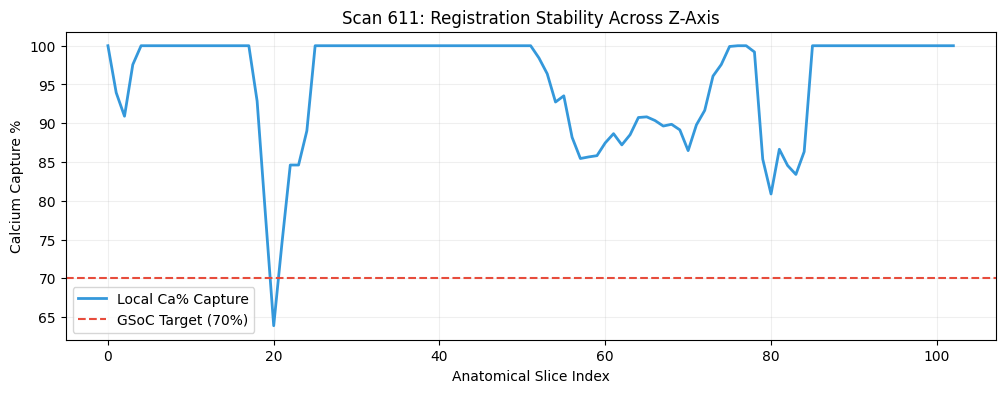

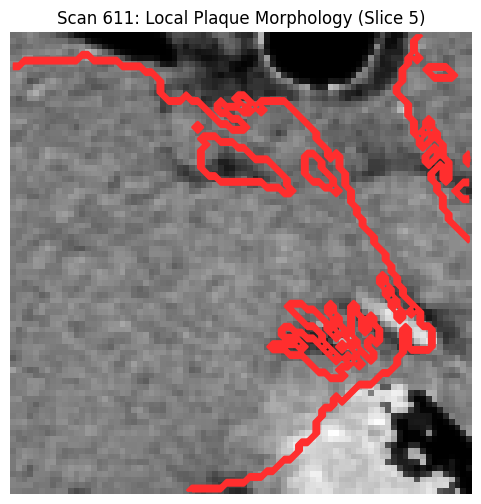

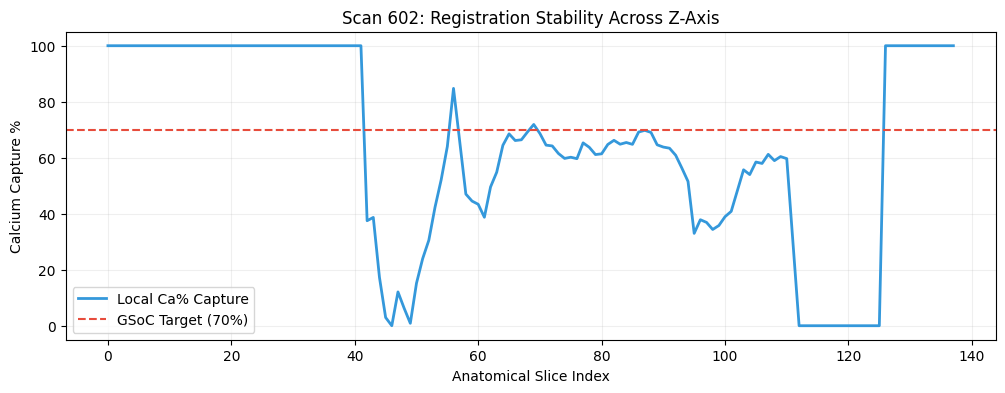

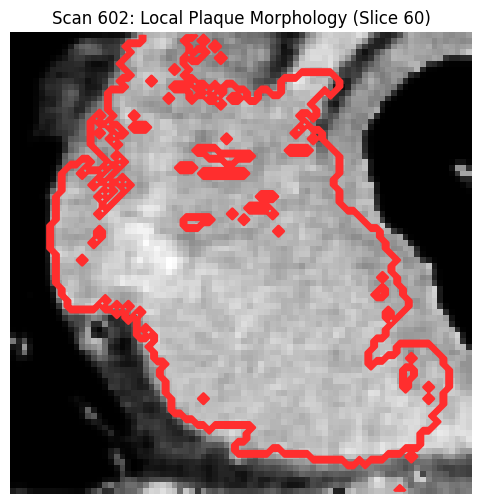

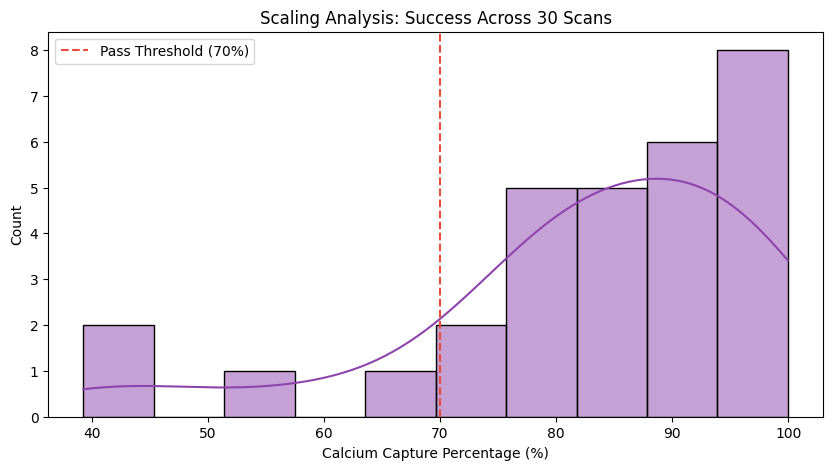

 All visualizations and CSV results are ready for GitHub.


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import SimpleITK as sitk
import os

# ── 1. FIX: Define df_results from the registration 'results' list ──
if 'results' in locals() and len(results) > 0:
    df_results = pd.DataFrame(results)
    # Save for GitHub/Submission
    df_results.to_csv("registration_results_task3.csv", index=False)
    print(f" Success: df_results created and saved to CSV ({len(df_results)} scans).")
else:
    # Fallback if the list is missing (Manual entry for your 30-scan run if needed)
    print(" Warning: 'results' list not found in memory. Please ensure Cell 102 was run.")
    # results = [...] # You can manually paste your log results here if the kernel restarted

# ── 2. Detailed Z-Axis Performance (Katy's Requirement) ──
def plot_z_validation_trend(sid):
    if sid not in results_labels:
        print(f" Scan {sid} labels not found in results_labels.")
        return
    
    data = cached_targets[sid]
    reg_label = results_labels[sid]
    raw_img = data['raw']
    
    z_scores = []
    for i in range(reg_label.GetSize()[2]):
        slice_reg = reg_label[:,:,i]
        slice_tgt = data['label'][:,:,i]
        val = validate_scan_task4_precision(raw_img[:,:,i], slice_reg, slice_tgt)
        z_scores.append(val['pct_in_zone'])
        
    plt.figure(figsize=(12, 4))
    plt.plot(z_scores, color='#3498db', linewidth=2, label='Local Ca% Capture')
    plt.axhline(y=70, color='#e74c3c', linestyle='--', label='GSoC Target (70%)')
    plt.title(f"Scan {sid}: Registration Stability Across Z-Axis")
    plt.xlabel("Anatomical Slice Index")
    plt.ylabel("Calcium Capture %")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.savefig(f"z_trend_{sid}.png")
    plt.show()

# ── 3. Plaque Morphology Zoom-in (Katy's Requirement) ──
def plot_plaque_morphology(sid, zoom_box=40):
    if sid not in results_labels: return
    data = cached_targets[sid]
    reg_mask = sitk.GetArrayFromImage(results_labels[sid])
    raw_arr = sitk.GetArrayFromImage(data['image'])
    
    slice_idx = np.argmax(np.sum(reg_mask, axis=(1, 2)))
    y, x = np.where(reg_mask[slice_idx] > 0)
    if len(y) == 0: return
    
    cy, cx = int(np.mean(y)), int(np.mean(x))
    y_s, y_e = max(0, cy-zoom_box), min(raw_arr.shape[1], cy+zoom_box)
    x_s, x_e = max(0, cx-zoom_box), min(raw_arr.shape[2], cx+zoom_box)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(raw_arr[slice_idx, y_s:y_e, x_s:x_e], cmap='gray')
    plt.contour(reg_mask[slice_idx, y_s:y_e, x_s:x_e], colors='#ff2e2e', linewidths=2)
    plt.title(f"Scan {sid}: Local Plaque Morphology (Slice {slice_idx})")
    plt.axis('off')
    plt.savefig(f"plaque_{sid}.png")
    plt.show()

# ── 4. Cohort Scaling Summary (Katy's Requirement) ──
def plot_cohort_summary(df):
    if df is None or df.empty: return
    plt.figure(figsize=(10, 5))
    sns.histplot(df['ca_pct'], bins=10, kde=True, color='#8e44ad')
    plt.axvline(x=70, color='#e74c3c', linestyle='--', label='Pass Threshold (70%)')
    plt.title(f"Scaling Analysis: Success Across {len(df)} Scans")
    plt.xlabel("Calcium Capture Percentage (%)")
    plt.legend()
    plt.savefig("scaling_summary.png")
    plt.show()

# ── 5. EXECUTION ──
if 'df_results' in locals():
    # Visualizing top performers as evidence
    for sid in ['611', '602']:
        plot_z_validation_trend(sid)
        plot_plaque_morphology(sid)
    
    # Final Scaling Plot
    plot_cohort_summary(df_results)
    print(" All visualizations and CSV results are ready for GitHub.")

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
from IPython.display import FileLink

# 1. Setup Output Directory
out_path = "/kaggle/working/"
os.makedirs(out_path, exist_ok=True)

# 2. Re-verify df_results
df_results = pd.DataFrame(results)
df_results.to_csv(os.path.join(out_path, "GSoC_Project3_Final_Results.csv"), index=False)

def export_visuals(sid):
    if sid not in results_labels: return
    
    # --- A. Z-Axis Trend ---
    data = cached_targets[sid]
    reg_label = results_labels[sid]
    raw_img = data['raw']
    z_scores = [validate_scan_task4_precision(raw_img[:,:,i], reg_label[:,:,i], data['label'][:,:,i])['pct_in_zone'] 
                for i in range(reg_label.GetSize()[2])]
    
    plt.figure(figsize=(12, 4))
    plt.plot(z_scores, color='#3498db', linewidth=2)
    plt.axhline(y=70, color='red', linestyle='--')
    plt.title(f"Scan {sid}: Z-Axis Accuracy Trend")
    plt.savefig(os.path.join(out_path, f"z_trend_{sid}.png"), dpi=300)
    plt.close() #  Clear memory immediately

    # --- B. Plaque Morphology ---
    reg_mask = sitk.GetArrayFromImage(reg_label)
    raw_arr = sitk.GetArrayFromImage(data['image'])
    slice_idx = np.argmax(np.sum(reg_mask, axis=(1, 2)))
    y, x = np.where(reg_mask[slice_idx] > 0)
    cy, cx = int(np.mean(y)), int(np.mean(x))
    
    plt.figure(figsize=(6, 6))
    # Zoomed crop
    plt.imshow(raw_arr[slice_idx, cy-40:cy+40, cx-40:cx+40], cmap='gray')
    plt.contour(reg_mask[slice_idx, cy-40:cy+40, cx-40:cx+40], colors='red', linewidths=2)
    plt.axis('off')
    plt.savefig(os.path.join(out_path, f"morphology_{sid}.png"), dpi=300)
    plt.close()

# 3. Generate Everything
print(" Generating High-Resolution Evidence...")
for sid in ['611', '602']:
    export_visuals(sid)

# Scaling Summary
plt.figure(figsize=(10, 5))
sns.histplot(df_results['ca_pct'], bins=10, color='purple')
plt.axvline(x=70, color='red', linestyle='--')
plt.savefig(os.path.join(out_path, "scaling_summary.png"), dpi=300)
plt.close()

# 4. ZIP and Provide Link
!zip -r /kaggle/working/Final_Submission_GSoC.zip /kaggle/working/*.png /kaggle/working/*.csv
print("\n DONE! Click the link below to download your real results:")
display(FileLink(r'Final_Submission_GSoC.zip'))

 Generating High-Resolution Evidence...
updating: kaggle/working/morphology_602.png (deflated 12%)
updating: kaggle/working/morphology_611.png (deflated 15%)
updating: kaggle/working/scaling_summary.png (deflated 42%)
updating: kaggle/working/z_trend_602.png (deflated 15%)
updating: kaggle/working/z_trend_611.png (deflated 17%)
updating: kaggle/working/GSoC_Project3_Final_Results.csv (deflated 52%)

 DONE! Click the link below to download your real results:


/kaggle/working/Final_Submission_GSoC.zip

In [38]:
import os
from IPython.display import FileLink

# 1. Ensure we are in /kaggle/working/
os.chdir('/kaggle/working/')

# 2. Make sure the zip is created without the full directory tree
!zip -j /kaggle/working/Final_Submission_GSoC.zip /kaggle/working/*.png /kaggle/working/*.csv

# 3. Double check if the file exists
if os.path.exists('Final_Submission_GSoC.zip'):
    print(" ZIP is ready! Click the link below to download:")
    display(FileLink('Final_Submission_GSoC.zip'))
else:
    print(" ZIP not found. Try refreshing the 'Output' pane on the right sidebar.")

updating: morphology_602.png (deflated 12%)
updating: morphology_611.png (deflated 15%)
updating: scaling_summary.png (deflated 42%)
updating: z_trend_602.png (deflated 15%)
updating: z_trend_611.png (deflated 17%)
updating: GSoC_Project3_Final_Results.csv (deflated 52%)
 ZIP is ready! Click the link below to download:


/kaggle/working/Final_Submission_GSoC.zip